In [7]:
import pandas as pd

df = pd.read_csv("eda_data.csv")

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [ ]:
df = pd.read_csv("eda_data.csv")

print("Original shape:", df.shape)
print(df.head())

Original shape: (742, 33)
   Unnamed: 0                  Job Title              Salary Estimate  \
0           0             Data Scientist   $53K-$91K (Glassdoor est.)   
1           1  Healthcare Data Scientist  $63K-$112K (Glassdoor est.)   
2           2             Data Scientist   $80K-$90K (Glassdoor est.)   
3           3             Data Scientist   $56K-$97K (Glassdoor est.)   
4           4             Data Scientist  $86K-$143K (Glassdoor est.)   

                                     Job Description  Rating  \
0  Data Scientist\nLocation: Albuquerque, NM\nEdu...     3.8   
1  What You Will Do:\n\nI. General Summary\n\nThe...     3.4   
2  KnowBe4, Inc. is a high growth information sec...     4.8   
3  *Organization and Job ID**\nJob ID: 310709\n\n...     3.8   
4  Data Scientist\nAffinity Solutions / Marketing...     2.9   

                                 Company Name         Location  \
0                      Tecolote Research\n3.8  Albuquerque, NM   
1  University of M

In [ ]:
df = df[['age', 'python_yn', 'spark', 'aws', 'excel', 'avg_salary']]

# Handle missing values
df = df.fillna(df.mean(numeric_only=True))


In [ ]:
threshold = df['avg_salary'].median()
df['HighSalary'] = (df['avg_salary'] > threshold).astype(int)

print("\nTarget distribution:")
print(df['HighSalary'].value_counts())


Target distribution:
HighSalary
0    374
1    368
Name: count, dtype: int64


In [ ]:
X = df[['age', 'python_yn', 'spark', 'aws', 'excel']]
y = df['HighSalary']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)


=== Model Evaluation ===
Accuracy: 0.738255033557047
ROC-AUC: 0.8050648882480174

Confusion Matrix:
[[57 16]
 [23 53]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.78      0.75        73
           1       0.77      0.70      0.73        76

    accuracy                           0.74       149
   macro avg       0.74      0.74      0.74       149
weighted avg       0.74      0.74      0.74       149



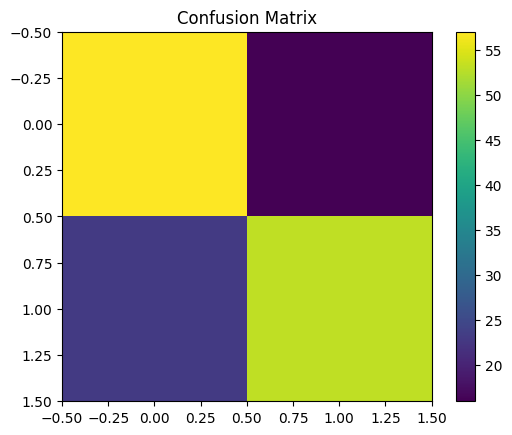

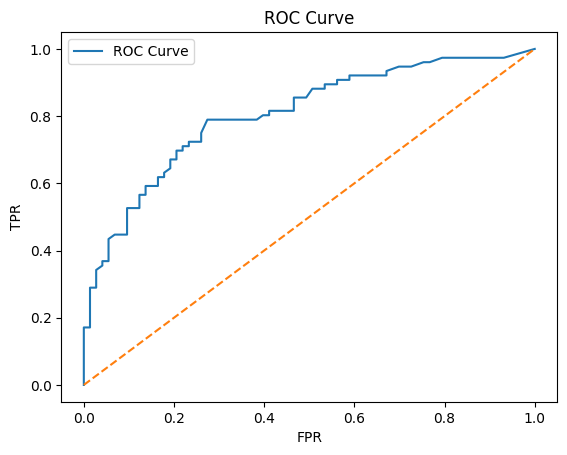

In [ ]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n=== Model Evaluation ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ======================
# 📊 Confusion Matrix Plot
# ======================
plt.imshow(confusion_matrix(y_test, y_pred))
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

# ======================
# 📊 ROC Curve
# ======================
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

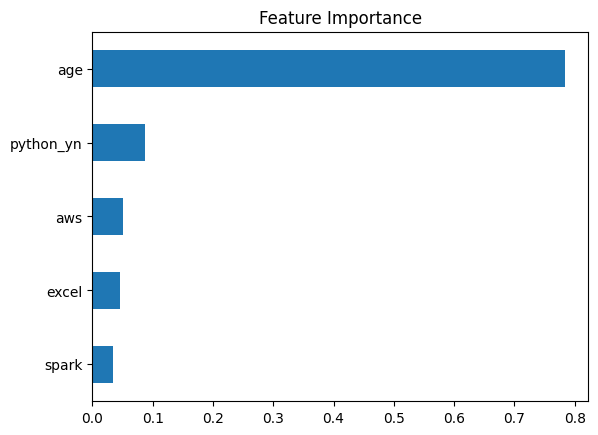

In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns)

importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [ ]:
print("\n=== Predict New Data ===")

new_data = pd.DataFrame({
    'age': [28],
    'python_yn': [1],
    'spark': [0],
    'aws': [1],
    'excel': [1]
})

new_scaled = scaler.transform(new_data)
prediction = model.predict(new_scaled)

if prediction[0] == 1:
    print("Prediction: High Salary")
else:
    print("Prediction: Low Salary")


=== Predict New Data ===
Prediction: High Salary
